# Regression with uncertainty estimation using `CatboostRegressorMother`

In this tutorial, we solve a regression problem to predict __calc__ from the molecules represented in __SMILES__ as well as estimating __knowledge uncertainty__ for each data point. You can find further explanations about the data and the uncertainty in the following cells below.

`CatboostRegressor` offers multiple ways of estimating uncertainties from the data while modeling. Here, we cover three different loss functions for regression and uncertainty estimation:

1. [RMSE](###-1.-RMSE-loss):
    the most basic loss function for regression to decrease the root mean square error. 
2. [RMSEWithUncertainty](###-2.-RMSEWithUncertainty-loss):
    a loss function to estimate both data and knowledge uncertainties training the model with the RMSE loss. Find more details [here](https://catboost.ai/docs/en/references/uncertainty#regression).
3. [MultiQuantile](###-3.-MultiQuantile-loss):
    a loss function to predict [quantiles](https://en.wikipedia.org/wiki/Quantile#:~:text=In%20statistics%20and%20probability%2C%20quantiles,sample%20in%20the%20same%20way.) of the predicted values. For `CatboostRegressorMother`, this loss is automatically set when the user provides the __`quantiles` parameter__ (e.g., `quantiles=[0.1, 0.5, 0.9]`). This loss outputs values as many as the given number of quantiles for each data point, and the user can consider the standard deviation of those as an estimated uncertainty. 

You can find the __full list of available loss functions__ [here](https://catboost.ai/docs/en/concepts/loss-functions-regression).

In [1]:
from pathlib import Path
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr

import mother.ml as ml

from mother import cv as cv_module
from mother import feature_generation as fg
import mother.pipeline_utils as mother_takes_care
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer

import warnings

warnings.filterwarnings("ignore")
# Ensure plots are displayed inline
%matplotlib inline
logging.basicConfig(level=logging.INFO)

### _functions for plotting the results_

In [2]:
def plot_uncertainty_vs_error(
    data, knowledge_uncertainty_col, prediction_error_col, mae, rmse, r2, z_threshold=1.96, title="Dataset"
):
    """
    Plots knowledge uncertainty vs prediction error with statistical significance thresholds.

    Parameters:
        data (pd.DataFrame): DataFrame containing the data.
        knowledge_uncertainty_col (str): Column name for model uncertainty.
        prediction_error_col (str): Column name for prediction error.
        mae (float): Mean Absolute Error value.
        rmse (float): Root Mean Squared Error value.
        r2 (float): R-squared value.
        z_threshold (float): Z-score threshold for statistical significance (default: 1.96 for 95% CI).
    """
    # Calculate statistically significant residuals
    prediction_error = data[prediction_error_col]
    z_scores = (prediction_error - prediction_error.mean()) / prediction_error.std()
    significant_mask = z_scores > z_threshold
    error_significance = prediction_error.mean() + z_threshold * prediction_error.std()

    # Calculate statistically significant uncertainty values
    knowledge_uncertainty = data[knowledge_uncertainty_col]
    z_scores_uncertainty = (knowledge_uncertainty - knowledge_uncertainty.mean()) / knowledge_uncertainty.std()
    significant_mask_uncertainty = z_scores_uncertainty > z_threshold
    uncertainty_threshold = knowledge_uncertainty.mean() + z_threshold * knowledge_uncertainty.std()

    # Calculate Pearson correlation
    pearson, pval = pearsonr(data[knowledge_uncertainty_col], data[prediction_error_col])

    # Plot
    plt.figure(figsize=(10, 6))

    # set labels
    label = "err culmulative prob"
    label_2 = "uncertainty cumulative prob"
    data.loc[:, label] = significant_mask.apply(lambda x: "> 95%" if x else "< 95%")
    data.loc[:, label_2] = significant_mask_uncertainty.apply(lambda x: "> 95%" if x else "< 95%")
    data = data.sort_values(by=[label_2, label])

    # Plot all points
    sns.scatterplot(
        x=knowledge_uncertainty_col,
        y=prediction_error_col,
        data=data,
        hue=label,
        style=label_2,
        palette=["blue", "red"],
        s=80,
    )

    # Add significant threshold lines
    plt.axhline(y=error_significance, color="red", linestyle="--", linewidth=0.9, label="z=1.96 line in Error")
    plt.axvline(
        x=uncertainty_threshold, color="#456bb2", linestyle="--", linewidth=0.9, label="z=1.96 line in Uncertainty"
    )

    # Add trendline
    sns.regplot(
        x=knowledge_uncertainty_col,
        y=prediction_error_col,
        data=data,
        scatter=False,
        color="grey",
        line_kws={"linestyle": "-"},
    )

    # Add metrics text
    metrics_text = f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}"
    plt.text(
        x=1.11,
        y=0.01,
        s=metrics_text,
        transform=plt.gca().transAxes,
        fontsize=11,
        color="black",
        ha="right",
        va="bottom",
        bbox={"facecolor": "white", "alpha": 0.6, "edgecolor": "black", "boxstyle": "round"},
    )

    # Finalize plot
    plt.title(f"{title} (Pearson corr: {pearson:.2f}, p = {pval:.1e})")
    plt.xlabel("Knowledge Uncertainty", fontsize=12)
    plt.ylabel("Prediction Error", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# a function to plot the boxplot and coverage percentage


def plot_boxplot_and_coverage(data, knowledge_uncertainty_col, prediction_error_col, z_threshold=1.96, title="Dataset"):
    """
    Creates a figure with two subplots: a boxplot of prediction errors by uncertainty bins
    and a bar plot showing the coverage percentage of errors above a significance threshold.

    Parameters:
        data (pd.DataFrame): DataFrame containing the data.
        knowledge_uncertainty_col (str): Column name for knowledge uncertainty.
        prediction_error_col (str): Column name for prediction error.
        z_threshold (float): Z-score threshold for statistical significance (default: 1.96 for 95% CI).
    """
    # Bin knowledge uncertainty into quartiles
    data["uncertainty_bin"] = pd.qcut(
        data[knowledge_uncertainty_col], q=4, labels=["Low", "Medium", "High", "Very High"]
    )

    # Calculate statistically significant residuals
    prediction_error = data[prediction_error_col]
    error_significance = prediction_error.mean() + z_threshold * prediction_error.std()

    # Calculate coverage percentage (errors > threshold)
    bin_coverage = (
        data.groupby("uncertainty_bin")[prediction_error_col]
        .apply(lambda x: (x > error_significance).mean() * 100)
        .reset_index()
    )

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={"height_ratios": [3, 1], "hspace": 0.4})
    sns.set_style("whitegrid")

    # --- Plot 1: Boxplot of Errors by Uncertainty Bin ---
    sns.boxplot(
        x="uncertainty_bin",
        y=prediction_error_col,
        data=data,
        palette="Blues",
        showfliers=False,  # Hide outliers for cleaner plot
        width=0.6,
        ax=ax1,
    )

    # Add actual data points with jitter
    sns.stripplot(
        x="uncertainty_bin",
        y=prediction_error_col,
        data=data,
        color="black",
        alpha=0.4,
        jitter=0.2,
        size=4,
        ax=ax1,
    )

    # Add horizontal line for error significance
    ax1.axhline(y=error_significance, color="red", linestyle="--", alpha=0.9, label="Error Significance=95%")

    ax1.set_title(f"{title}", fontsize=14, pad=20)
    ax1.set_xlabel("Knowledge Uncertainty Bin (Quartiles)", fontsize=12)
    ax1.set_ylabel("Prediction Error", fontsize=12)
    ax1.tick_params(axis="both", labelsize=10)
    ax1.legend()

    # --- Plot 2: Coverage by Bin ---
    sns.barplot(
        x="uncertainty_bin",
        y=prediction_error_col,
        data=bin_coverage,
        palette="Oranges",
        hue="uncertainty_bin",
        dodge=False,
        ax=ax2,
    )

    ax2.set_title("Coverage Percentage (Error > Error Significance) by Uncertainty Bin", fontsize=14, pad=20)
    ax2.set_xlabel("Knowledge Uncertainty Bin (Quartiles)", fontsize=12)
    ax2.set_ylabel("% Above Threshold", fontsize=12)
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis="both", labelsize=10)

    # Add percentage labels on bars
    for p in ax2.patches:
        ax2.annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 9),
            textcoords="offset points",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

### Import Data
Load the data from the input file and limit the data to 100 rows for testing purposes.
The data file contains a column with the molecular structure (__Molecule__) and a column with the target value (__calc__).


In [3]:
input_file: Path = Path("../freesolv_train.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
data = data[["iupac", "smiles", "calc"]]
TARGET_COL = "calc"
data.head()

,iupac,smiles,calc
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-9.625
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-6.219
2,3-methylbut-1-ene,CC(C)C=C,2.452
3,2-ethylpyrazine,CCc1cnccn1,-5.809
4,heptan-1-ol,CCCCCCCO,-2.917


## Preprocessing
The preprocessing pipeline consists of two steps:
1. Standardize the molecular structure using the __StandardizerTransformer__.
2. Convert the standardized SMILES to a molecule object using the __SmilesToMolTransformer__.

In [4]:
preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
        # Add other column transformations here if needed
    ],
    memory=None,
).set_output(transform="pandas")

structure_data: pd.Series = data["smiles"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

mol_data.head()

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[06:21:50] Initializing Normalizer
[06:21:50] Initializing Normalizer
[06:21:50] Initializing MetalDisconnector
[06:21:50] Initializing Normalizer


,Molecule
0,<rdkit.Chem.rdchem.Mol object at 0x786a3fdd1ee0>
1,<rdkit.Chem.rdchem.Mol object at 0x786a3fdd1e00>
2,<rdkit.Chem.rdchem.Mol object at 0x786a3fdd1d20>
3,<rdkit.Chem.rdchem.Mol object at 0x786a3fdd35a0>
4,<rdkit.Chem.rdchem.Mol object at 0x786a3fdd1f50>


## Feature Generation
By combining multiple feature generators, we can create a feature matrix that contains various types of features. By default, we are combining _MACCS_ fingerprints, _Morgan_ fingerprints, and _Chemical Descriptors_.

In [5]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ],
).set_output(transform="pandas")


features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])

features.head()

INFO:mother.feature_generation.core:Calculating MACCS fingerprints


INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'radius': 2, 'fpSize': 1024, 'includeChirality': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'


,maccs__maccs_0,maccs__maccs_1,maccs__maccs_2,maccs__maccs_3,maccs__maccs_4,maccs__maccs_5,maccs__maccs_6,maccs__maccs_7,maccs__maccs_8,maccs__maccs_9,...,desc__fr_sulfide,desc__fr_sulfonamd,desc__fr_sulfone,desc__fr_term_acetylene,desc__fr_tetrazole,desc__fr_thiazole,desc__fr_thiocyan,desc__fr_thiophene,desc__fr_unbrch_alkane,desc__fr_urea
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0


## Grouping for Cross-Validation
To ensure that the training and validation sets do not contain similar molecules, we group the molecules based on their similarity. We use the Tanimoto similarity to group molecules with a similarity threshold of 0.7. 

In [6]:
# cv grouping
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.4)

groups: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])


cv = GroupKFold(n_splits=5)

print(f"{groups['tanimoto-group'].nunique()} groups found")

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.4
INFO:mother.cv.cv_methods:Found: 42 clusters


42 groups found


In [7]:
gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(features, data[TARGET_COL], groups=groups["tanimoto-group"].astype(int)))

# Subset the data
X_train, X_test = features.iloc[train_idx], features.iloc[test_idx]
y_train, y_test = data[TARGET_COL].iloc[train_idx], data[TARGET_COL].iloc[test_idx]

# Ensure no group overlap
train_groups = groups.iloc[train_idx]["tanimoto-group"].unique()
test_groups = groups.iloc[test_idx]["tanimoto-group"].unique()
print(f"Train groups: {len(train_groups)} (n={len(train_idx)})")
print(f"Test groups: {len(test_groups)} (n={len(test_idx)})")
assert len(set(train_groups) & set(test_groups)) == 0, "Group overlap detected!"

Train groups: 29 (n=35)
Test groups: 13 (n=15)


## Target prediction and uncertainty estimation using `CatboostRegressorMother`

### What is Uncertainty?
Establishing a measure of model reliability and prediction trustworthiness is crucial. Estimating the uncertainty associated with model predictions is a significant aspect in ML applications known as uncertainty prediction or quantification. Understanding uncertainty helps in identifying areas where the model may lack sufficient knowledge or where the data itself is inherently noisy.

### Types of Uncertainty
1- Epistemic Uncertainty (Knowledge Uncertainty):

- This type of uncertainty arises from the model's lack of knowledge about the data.
- It is typically higher in regions of the input space where the model has seen fewer examples during training.
- Epistemic uncertainty can be reduced by collecting more data in these regions or improving the model's capacity i.e., the chosen model archeticture and training process.

2- Aleatoric Uncertainty (Data Uncertainty):

- This type of uncertainty originates from data itself due to inherent noise, randomness in measurments, or loss of information.
- It cannot be reduced with more data or a better model, as it reflects the variability/noise-level in features.

### Why It is critical to estimate the uncertainty?
Quantifying data uncertainity can help detect overfitting, for example if the data uncertainty is higher than knowledge uncertainty, there could be a risk of overfitting.

if our goal is active learning, then we would like to detect novel inputs, and knowledge uncertainty can be used for that.

### Active learning 
is a machine learning paradigm where the model actively selects the most informative data points to label and include in the training set. Instead of passively using a fixed dataset, the model queries an oracle (e.g., a human annotator) for labels on data points where it is most uncertain or where additional information would improve its performance.
- One of the sampling strategies is Uncertainty Sampling:

    . The model identifies data points with the highest uncertainty (e.g., high epistemic uncertainty) and queries their labels. This ensures that the model focuses on learning from the most challenging or informative examples.

### How Mother supports the uncertainty estimation?

All models implemented in `mother.ml` supports the uncertainty estimation (if the original method supports it) with the `predict_uncertainty` function:
- `predict_uncertainty`: the regressor outputs the following columns
    - `mean_predictions` (Users can consider this as predicted values)
    - `knowledge_uncertainty`
    - `data_uncertainty`
    - `total_uncertainty`

_Please note that some of the columns have `None` values when the given loss does not support estimating a specific uncertainty_.

In `mother`, we implemented the `Catboost` uncertainty estimation using the [virtual ensembles](https://catboost.ai/docs/en/concepts/python-reference_virtual_ensembles_predict) algorithm provided by the original `Catboost` package. 

### <font color='grey'>_Note: Model Training pipeline for this tutorial_</font>

The model in this tutorial consists of two steps:
1. Feature selection using the __FeatureSelector__
2. Model training using the __CatboostRegressorMother__: A conventional Catboost regressor with hyperparameter tuning capabilities (used later)

`model_settings` and `pipeline_settings` below are the common settings for the __FeatureSelector__ and the __CatboostRegressorMother__, respectively, shared by all following experiments. 

In [8]:
model_settings = {
    "feature_selection_flags": ["DROP_CORRELATED", "DROP_CONSTANT", "DROP_DUPLICATES", "DROP_UNIMPORTANT"],
    "feature_selection_threshold": 1e-4,
    "correlation_threshold": 0.8,
    "algorithm": "catboost",
    "feature_selection_type": "catboost",
    "cv": cv,
    "cv_groups": groups,
    "cv_splits": 5,
}

pipeline_settings = {
    "remainder": "passthrough",
    "verbose_feature_names_out": False,
}
model_settings["target_type"] = "single_target"
model_settings["model_type"] = "regression"
model_settings["posterior_sampling"] = True


# Predict with uncertainty
virtual_ensembles_count = 100  # default is 10
thread_count = -1  # Use all available threads

### 1. RMSE loss

The RMSE loss function optimises model by reducing root mean square error between the predicted and the target values. 

In [9]:
model_uncertainty = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings, pipeline_settings=pipeline_settings
            ).set_output(transform="pandas"),
        ),
        (
            "ml_model",
            ml.CatboostRegressorMother(
                loss_function="RMSE",  # LOSS FUNCTION SET UP
                logging_level="Silent",
            ),
        ),
    ]
)

# fit the model to the training data
model_uncertainty.fit(X_train, y_train)

# predict and estimate the uncertainty for test data
df_res_rmse = model_uncertainty.predict_uncertainty(
    X=X_test,
    ml_model__n_ensembles=virtual_ensembles_count,
    ml_model__n_threads=thread_count,  # RETURN UNCERTAINTY
)
df_res_rmse.head()

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml:Loaded 9 model classes: CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, LassoClassifierBinaryMother, LassoClassifierMulticlassMother, LassoRegressorMother, RandomForestClassifierMother, RandomForestRegressorMother
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction


,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
4,-2.003575,0.000243,None,None
6,0.369835,0.006580,None,None
8,0.224318,0.000408,None,None
14,-1.408236,0.002298,None,None
15,-3.540225,0.000344,None,None


We compared the absolute error of the predicted values to the estimated uncertainty (figure below). The data points whose error is exceptionally high (>95% in the entire distribution) are coloured red, whereas the data points with a high uncertainty (also >95% in the entire distribution) are marked with the __x__ shape.

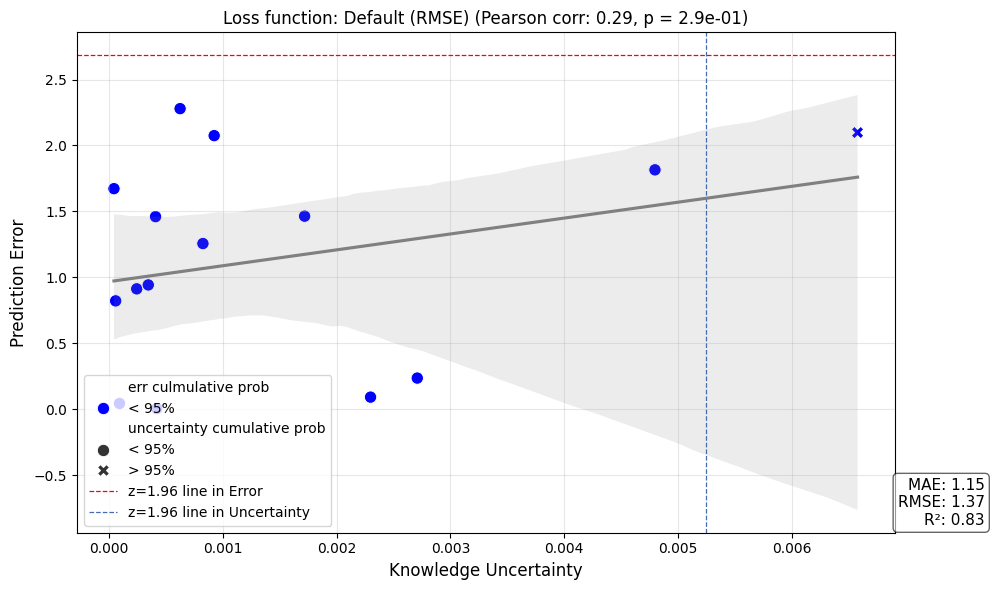

In [10]:
df_res_rmse["prediction_error"] = abs(y_test - df_res_rmse["mean_predictions"])

plot_uncertainty_vs_error(
    data=df_res_rmse,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    mae=mean_absolute_error(y_test, df_res_rmse["mean_predictions"]),
    rmse=root_mean_squared_error(y_test, df_res_rmse["mean_predictions"]),
    r2=r2_score(y_test, df_res_rmse["mean_predictions"]),
    title="Loss function: Default (RMSE)",
)

[ANOVA](https://en.wikipedia.org/wiki/Analysis_of_variance) is a statistical analysis method to compare the means of multiple groups to determine whether the given groups are likely different or not. Here, we use the ANOVA test to compare the 4-quantiles of estimated uncertainties. 

In [11]:
from scipy.stats import f_oneway

# Bin knowledge uncertainty into quartiles
df_res_rmse["uncertainty_bin"] = pd.qcut(
    df_res_rmse["knowledge_uncertainty"], q=4, labels=["Low", "Medium", "High", "Very High"]
)

# Perform one-way ANOVA test
groups = df_res_rmse.groupby("uncertainty_bin")["prediction_error"]

# Extract prediction errors for each group
low_group = groups.get_group("Low")
medium_group = groups.get_group("Medium")
high_group = groups.get_group("High")
very_high_group = groups.get_group("Very High")

# Perform ANOVA
f_stat, p_value = f_oneway(low_group, medium_group, high_group, very_high_group)

# Print the results
print("ANOVA Test Results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpret the results
if p_value < 0.05:
    print("The groups are statistically significantly different (p < 0.05).")
else:
    print("The groups are not statistically significantly different (p >= 0.05).")

ANOVA Test Results:
F-statistic: 0.4614
P-value: 7.1485e-01
The groups are not statistically significantly different (p >= 0.05).


From the box plot and the histogram below, we conclude that high uncertainty values do not represent high errors, meaning the estimated uncertainty by the RMSE loss may not be the best performance indicator for the unlabelled data points in our analysis. 

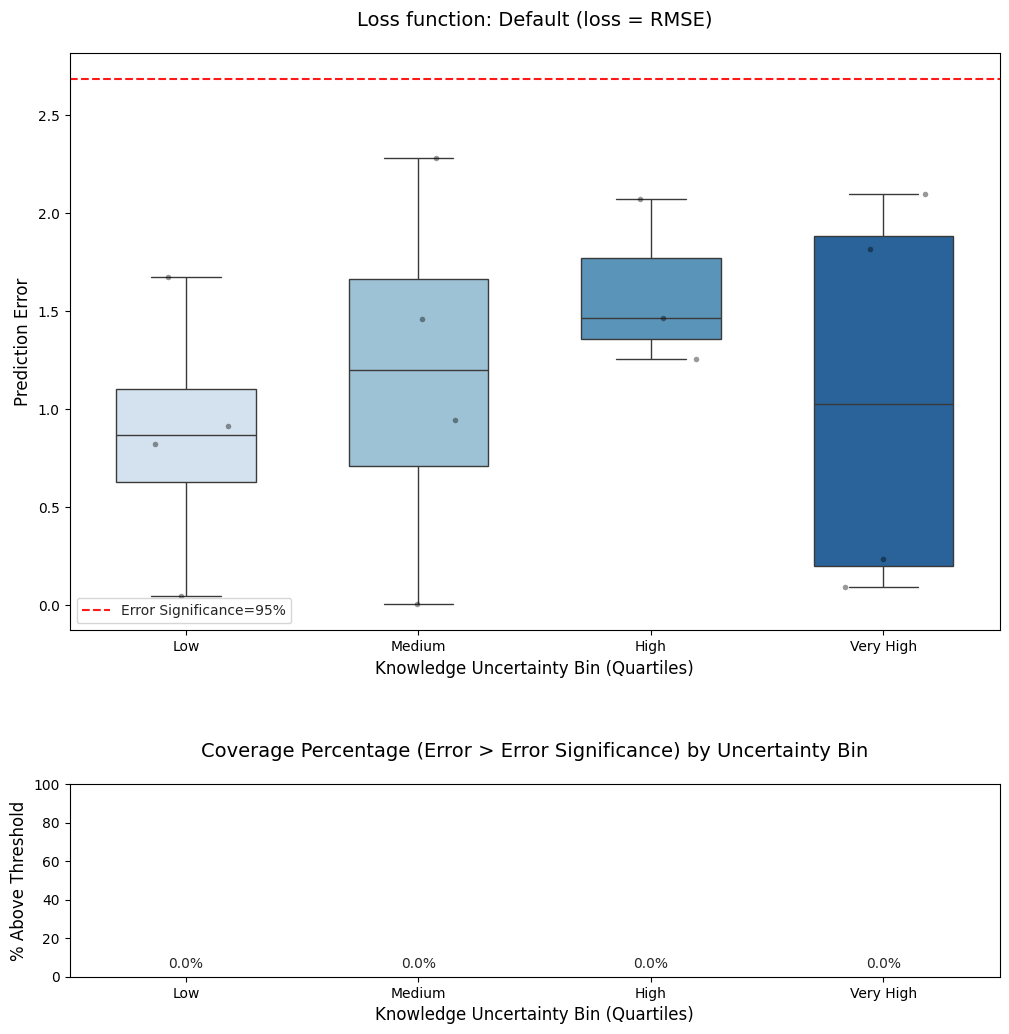

In [12]:
plot_boxplot_and_coverage(
    data=df_res_rmse,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    title="Loss function: Default (loss = RMSE)",
)

### 2. RMSEWithUncertainty loss

The RMSEWithUncertainty loss also optimises the model based on the discrepancy between the targeted and the predicted values, but using a Gaussian distribution whose mean value is the target. The biggested advantage of using the RMSEWithUncertainty loss is that the model can estimate __data uncertainty__ as well as knowledge uncertainty. According to the [Catboost official tutorial](https://catboost.ai/docs/en/references/uncertainty), the data uncertainty for a regression task is calculated as the mean of variances (of the Gaussian distribution) estimated via an ensemble. 

In [24]:
model_uncertainty_2 = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings, pipeline_settings=pipeline_settings
            ).set_output(transform="pandas"),
        ),
        (
            "ml_model",
            ml.CatboostRegressorMother(
                loss_function="RMSEWithUncertainty",  # LOSS SET UP
                logging_level="Silent",
            ),
        ),
    ]
)

# fit the model to data
model_uncertainty_2.fit(X_train, y_train)

# predict the target values
df_res = model_uncertainty_2.predict_uncertainty(
    X=X_test,
    ml_model__n_ensembles=virtual_ensembles_count,
    ml_model__n_threads=thread_count,  # RETURN UNCERTAINTY
)

df_res.head()

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.ml.utils:Using catboost's builtin uncertainty prediction


,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
4,-1.839377,0.000523,0.030101,0.030625
6,0.146479,0.000160,0.052744,0.052904
8,0.108022,0.000104,0.060877,0.060981
14,-1.805563,0.001152,0.009625,0.010777
15,-3.493552,0.000188,0.045840,0.046028


Firstly, we present the estimated knowledge uncertainty to the absolute error but, similarly to the result from the RMSE loss, the uncertainty values do not correlate with the error values. 

In [14]:
df_res

,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
4,-1.839377,0.000523,0.030101,0.030625
6,0.146479,0.000160,0.052744,0.052904
8,0.108022,0.000104,0.060877,0.060981
14,-1.805563,0.001152,0.009625,0.010777
15,-3.493552,0.000188,0.045840,0.046028
20,-5.818530,0.001132,0.095181,0.096313
22,-3.032570,0.000987,0.016228,0.017215
28,-3.227766,0.000357,0.035036,0.035392
29,-4.998138,0.000340,0.095095,0.095436
30,-0.779336,0.002354,0.035206,0.037561


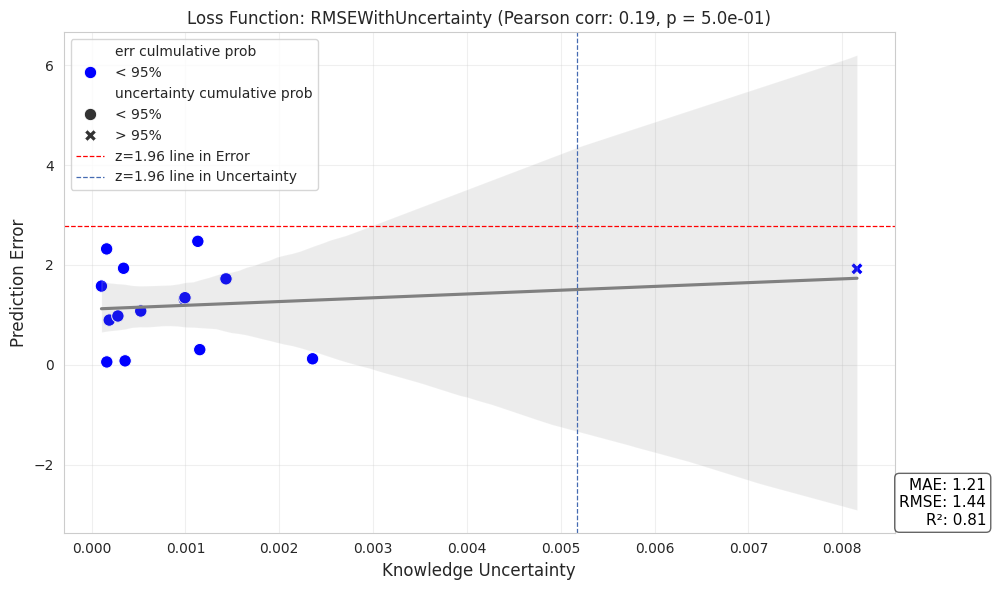

In [15]:
df_res["prediction_error"] = abs(y_test - df_res["mean_predictions"])

plot_uncertainty_vs_error(
    data=df_res,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    mae=mean_absolute_error(y_test, df_res["mean_predictions"]),
    rmse=root_mean_squared_error(y_test, df_res["mean_predictions"]),
    r2=r2_score(y_test, df_res["mean_predictions"]),
    title="Loss Function: RMSEWithUncertainty",
)

However, when we analysed the error with the total uncertainty (data uncertainty + knowledge uncertainty), the correlation value significantly improved.

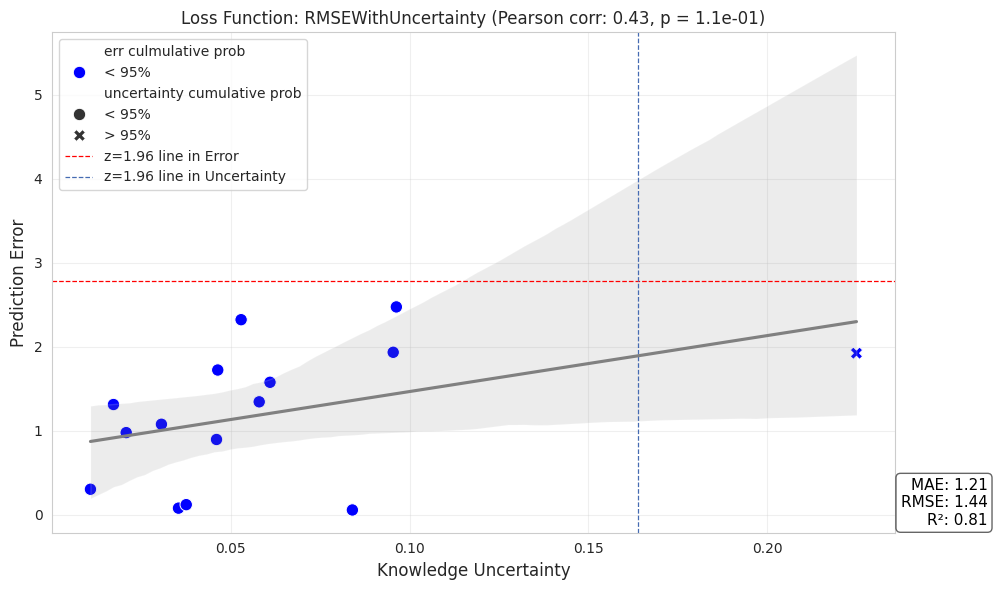

In [16]:
plot_uncertainty_vs_error(
    data=df_res,
    knowledge_uncertainty_col="total_uncertainty",
    prediction_error_col="prediction_error",
    mae=mean_absolute_error(y_test, df_res["mean_predictions"]),
    rmse=root_mean_squared_error(y_test, df_res["mean_predictions"]),
    r2=r2_score(y_test, df_res["mean_predictions"]),
    title="Loss Function: RMSEWithUncertainty",
)

We also found that all of the data points with a high error (>95% of the entire distribution) are in the 'very high' bin of the 4-quantiles of estimated uncertainties.

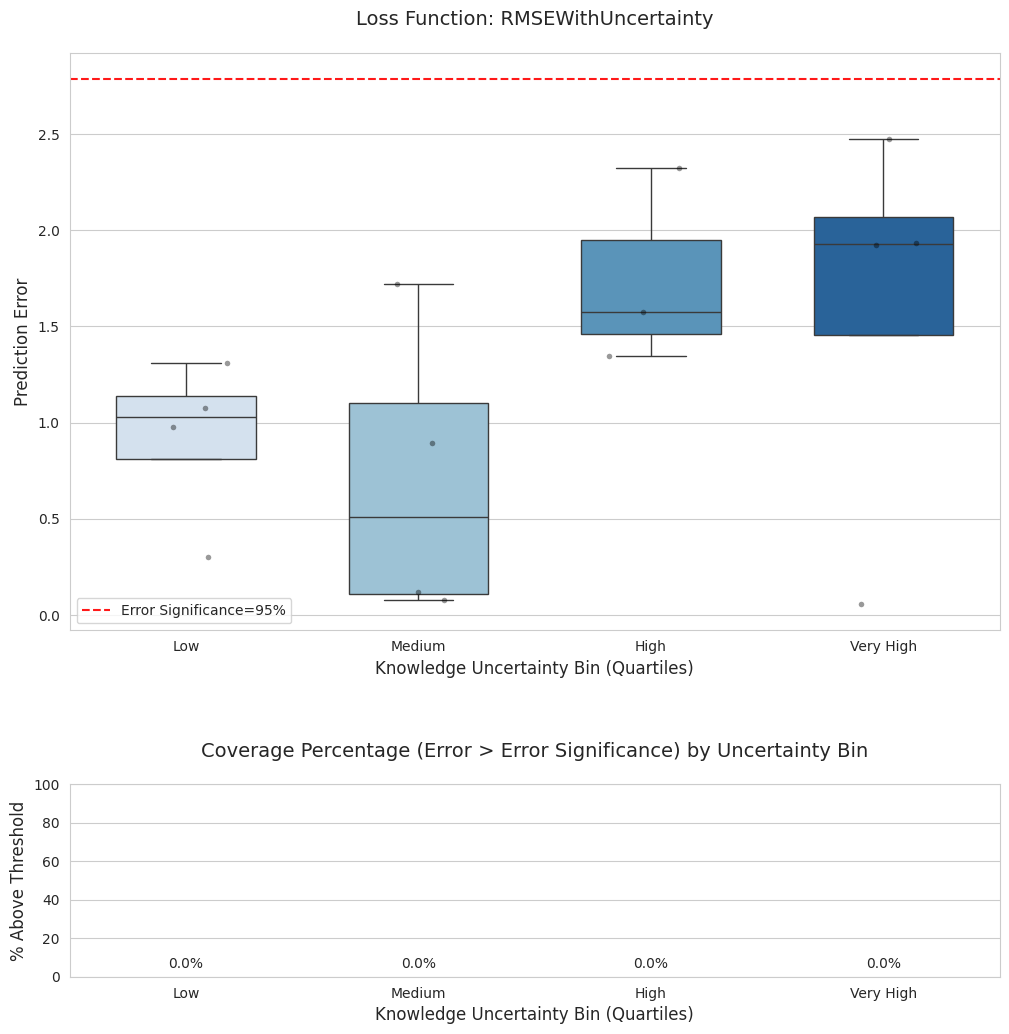

In [17]:
plot_boxplot_and_coverage(
    data=df_res,
    knowledge_uncertainty_col="total_uncertainty",
    prediction_error_col="prediction_error",
    title="Loss Function: RMSEWithUncertainty",
)

### 3. MultiQuantile loss

[Quantile](https://en.wikipedia.org/wiki/Quantile) estimation provides us the overall distribution of the predicted values, which can be used for uncertainty estimation. `CatboostRegressor` supports the MultiQuantile loss which estimates given quantiles of data points. Here, we use the model trained with the MultiQnuantile loss to calculate the uncertainty of test data. 

<span style="color:red">Please note that giving `quantiles` parameter automatically sets up the loss function to MultiQuantile. In this tutorial, we estimate five quantiles of 0.1, 0.3, 0.5, 0.7, and 0.9.</span>.


In [18]:
model_quantiles = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings, pipeline_settings=pipeline_settings
            ).set_output(transform="pandas"),
        ),
        (
            "ml_model",
            ml.CatboostRegressorMother(
                quantiles=[0.1, 0.3, 0.5, 0.7, 0.9],  # SET UP QUANTILES instead of LOSS
                logging_level="Silent",
            ),
        ),
    ]
)

# fit the model to data
model_quantiles.fit(X_train, y_train)

df_res_quant = model_quantiles.predict_uncertainty(
    X=X_test,
    ml_model__n_ensembles=virtual_ensembles_count,
    ml_model__n_threads=thread_count,  # SET UP uncertainty
)

# Display the predictions with uncertainty
df_res_quant.head()

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


,quantile_0.1,quantile_0.3,quantile_0.5,quantile_0.7,quantile_0.9
4,-2.382973,-1.982047,-1.976462,-1.709484,-1.622284
6,-0.544841,0.100461,0.394640,0.409680,0.982939
8,-0.842531,-0.102971,0.239790,0.114284,0.703760
14,-2.785992,-2.457974,-2.119082,-1.979338,-1.510511
15,-4.558384,-4.029381,-3.395314,-2.834198,-2.166083


We again performed the comparison analysis between the estimated uncertainty and the absolute error. Since the output of the MultiQuantile loss is only predicted values for each quantile, we calculated the final prediction and the uncertainty as follow:
- predcition: the value of quantile = 0.5 (median of the distribution)
- knowledge uncertainty: standard deviation of the estimated quantiles 

The result shows that the correlation is even higher than the total uncertainty result of RMSEWithUncertainty, however, the MAE and RMSE values are lower. 

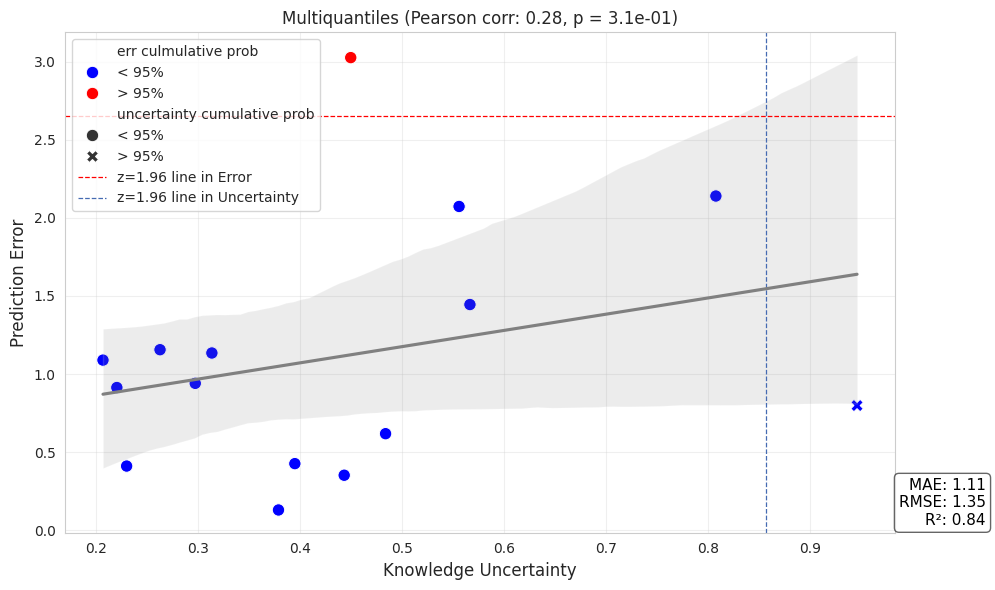

In [19]:
# uncertainty = std(estimated quantiles)
df_res_quant["knowledge_uncertainty"] = df_res_quant.std(axis=1)
# predicted value = median (q=0.5) of the estimates
df_res_quant["target_pred"] = df_res_quant["quantile_0.5"]

df_res_quant["prediction_error"] = abs(y_test - df_res_quant["target_pred"])

plot_uncertainty_vs_error(
    data=df_res_quant,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    mae=mean_absolute_error(y_test, df_res_quant["target_pred"]),
    rmse=root_mean_squared_error(y_test, df_res_quant["target_pred"]),
    r2=r2_score(y_test, df_res_quant["target_pred"]),
    title="Multiquantiles",
)

The boxplot and the histogram below also show that all data points with a high error are in the 'very high' bin of the uncertainty quartiles, meaning the uncertainty value could be an indicator for data point selection for optimisation (e.g., in the case of active learning).

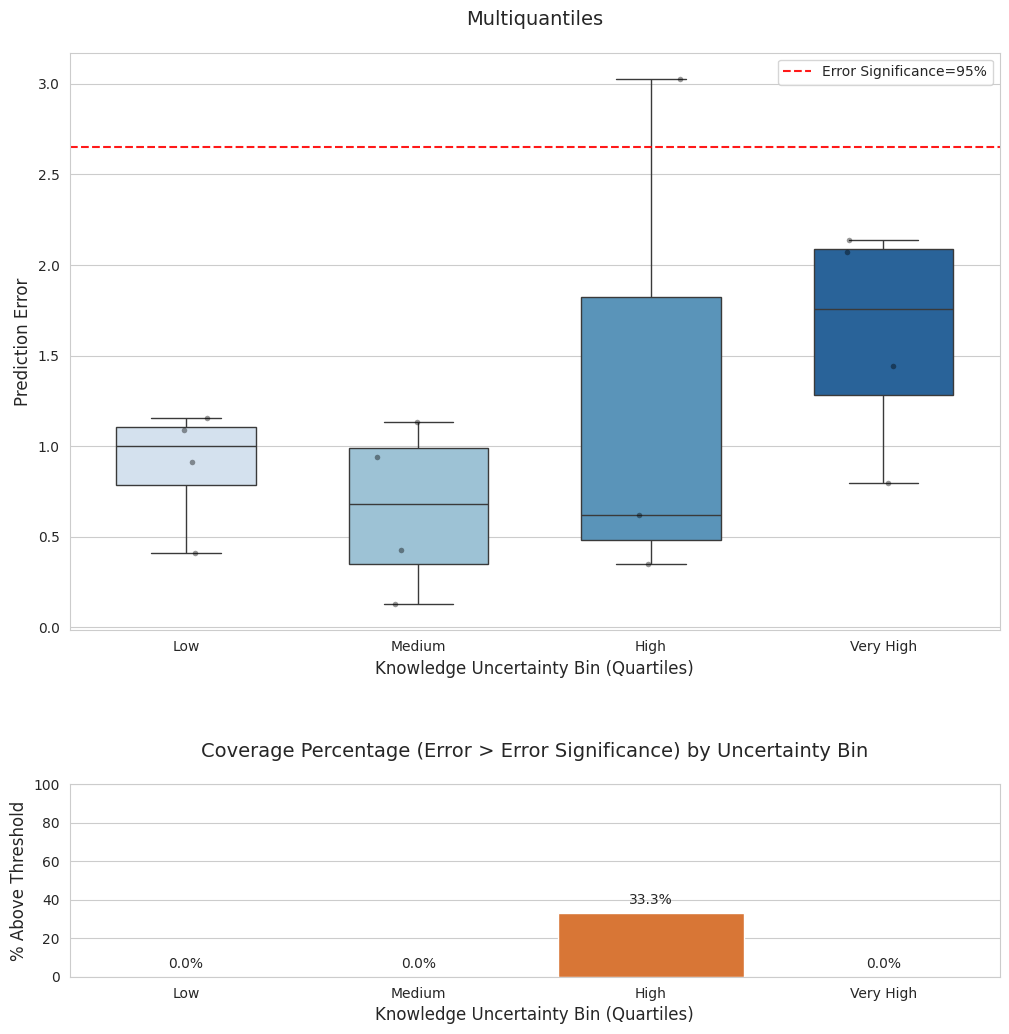

In [20]:
plot_boxplot_and_coverage(
    data=df_res_quant,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    title="Multiquantiles",
)

In [21]:
model_CatboostGaussianProcess = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings, pipeline_settings=pipeline_settings
            ).set_output(transform="pandas"),
        ),
        (
            "ml_model",
            ml.CatboostGaussianProcessRegressorMother(
                samples=10, prior_iterations=500, learning_rate=0.1, depth=6, verbose=False
            ),
        ),
    ]
)

# Fit the model
model_CatboostGaussianProcess.fit(X_train, y_train)
# Predict mean and knowledge uncertainty
mean_predictions_model_uncertainty = model_CatboostGaussianProcess.predict_uncertainty(X_test)
model_uncertainty = model_CatboostGaussianProcess.predict_uncertainty(X_test, uncertainty_for_opt=True)

# Display results
print(mean_predictions_model_uncertainty[:5])
print(model_uncertainty[:5])

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator


ValueError: predict_uncertainty() got unexpected keyword argument(s): ['uncertainty_for_opt']. Parameters must follow the pattern 'step_name__param_name' where step_name is one of: ['feature_selector', 'ml_model']. For example: ml_model__n_ensembles=100

In [ ]:
df_res_gauss = pd.DataFrame(
    {
        "test_expt": y_test,
        "target_pred": mean_predictions_model_uncertainty["mean_predictions"],
        "prediction_error": abs(y_test - mean_predictions_model_uncertainty["mean_predictions"]),
        "knowledge_uncertainty": mean_predictions_model_uncertainty["knowledge_uncertainty"],
    }
)

rmse = root_mean_squared_error(y_test, df_res_gauss["target_pred"])
mae = mean_absolute_error(y_test, df_res_gauss["target_pred"])
r2 = r2_score(y_test, df_res_gauss["target_pred"])
print(f"RMSE: {rmse:.1f}")
print(f"MAE: {mae:.1f}")
print(f"R2: {r2:.1f}")

RMSE: 1.4
MAE: 1.1
R2: 0.8


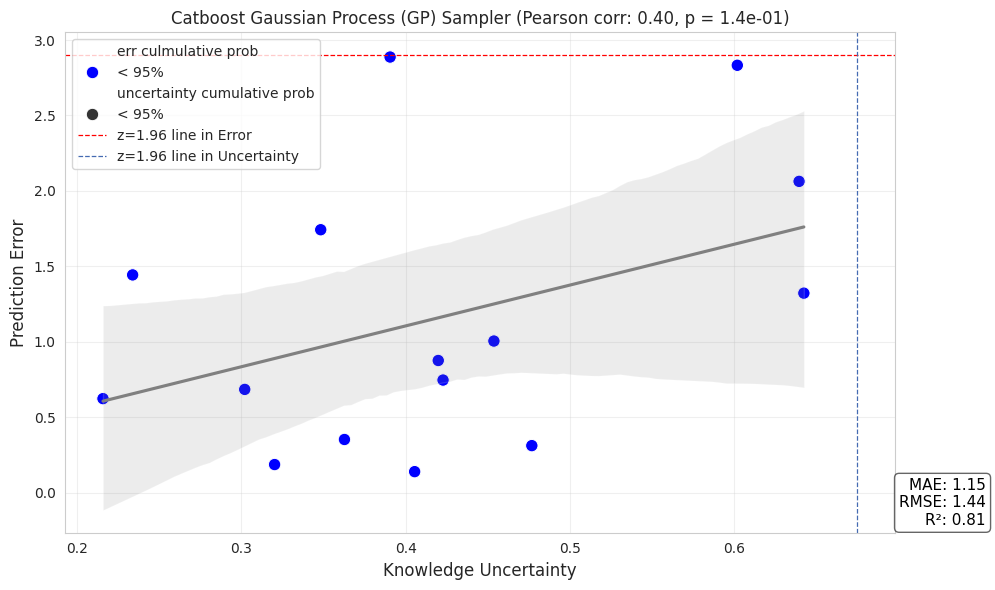

In [ ]:
plot_uncertainty_vs_error(
    data=df_res_gauss,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    mae=mae,
    rmse=rmse,
    r2=r2,
    title="Catboost Gaussian Process (GP) Sampler",
)

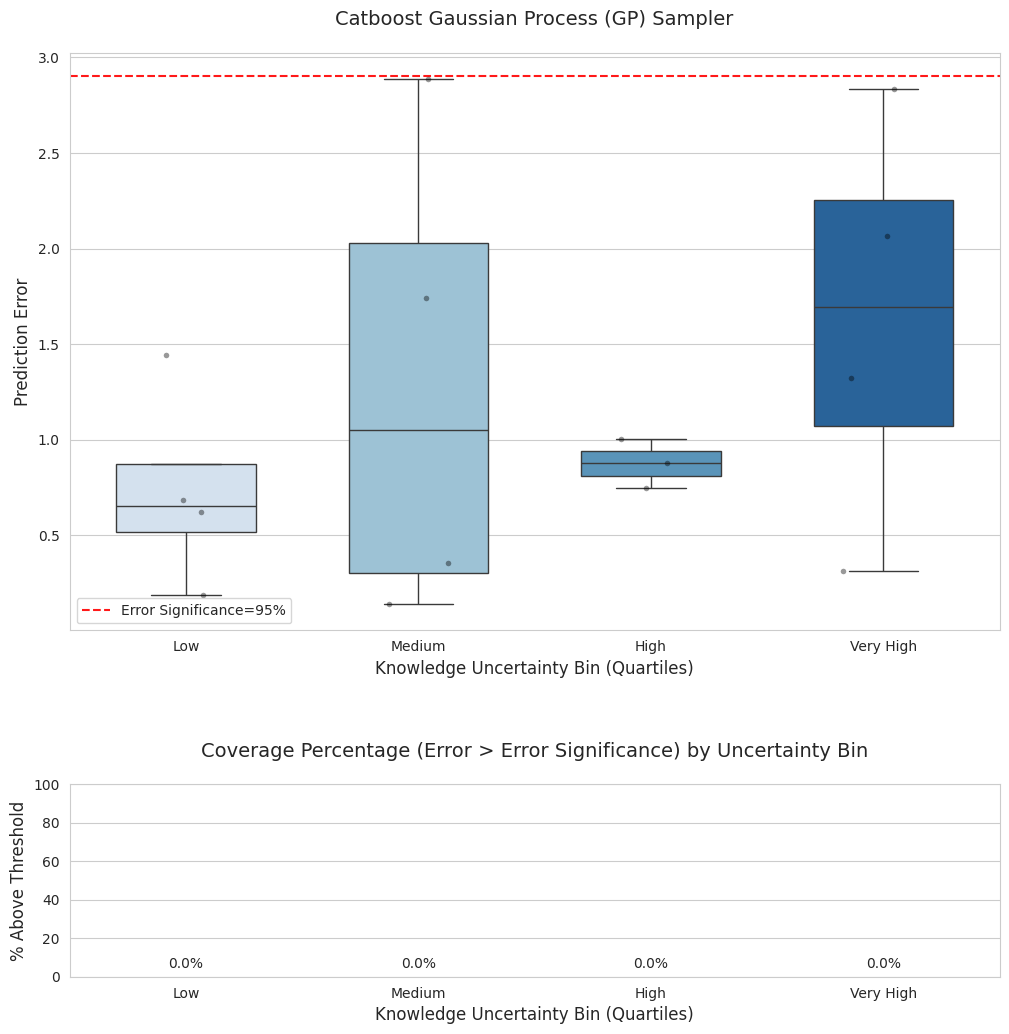

In [ ]:
plot_boxplot_and_coverage(
    data=df_res_gauss,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    title="Catboost Gaussian Process (GP) Sampler",
)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.utils import resample


def bootstrap_model_uncertainty(model, X_train, y_train, X_test, n_bootstrap=10, random_state=42):
    """
    Perform bootstrapping to estimate model uncertainty.
    Returns:
        pd.DataFrame: DataFrame containing mean predictions and model uncertainty.
    """
    np.random.seed(random_state)
    bootstrap_predictions = []

    # Perform bootstrapping
    for i in range(n_bootstrap):
        # Resample the training data
        X_resampled, y_resampled = resample(X_train, y_train, random_state=random_state + i)

        # Clone and train the model on the resampled data
        model_clone = ml.PipelineWithHyperparameterRooting(
            [
                (
                    "feature_selector",
                    mother_takes_care.get_feature_selection_pipeline(
                        settings=model_settings, pipeline_settings=pipeline_settings
                    ).set_output(transform="pandas"),
                ),
                ("ml_model", ml.CatboostRegressorMother(target_type="single_target", logging_level="Silent")),
            ]
        )
        model_clone.fit(X_resampled, y_resampled)

        # Predict on the test set
        predictions = model_clone.predict(X_test)
        bootstrap_predictions.append(predictions)

    # Convert predictions to a NumPy array
    bootstrap_predictions = np.array(bootstrap_predictions)

    # Calculate mean predictions and uncertainty (standard deviation)
    mean_predictions = bootstrap_predictions.mean(axis=0)
    model_uncertainty = bootstrap_predictions.std(axis=0)

    # Return results as a DataFrame
    results = pd.DataFrame({"mean_predictions": mean_predictions, "knowledge_uncertainty": model_uncertainty})

    return results

In [ ]:
# Perform bootstrapping
bootstrap_results = bootstrap_model_uncertainty(
    model=model_uncertainty,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    n_bootstrap=50,  # Number of bootstrap iterations
)

# Display results
print(bootstrap_results.head())

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.ml.estimators:Finished catboost feature importance calculation
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Initialized catboost feature importance estimator
INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up catboost importance feature selection
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.ml.

   mean_predictions  knowledge_uncertainty
0         -2.578419               0.376100
1         -0.497819               1.024325
2         -0.682988               0.651518
3         -1.814279               0.661423
4         -3.526538               0.438147


In [ ]:
print(f"y_test shape: {y_test.shape}")
print(f"bootstrap_results['mean_predictions'] shape: {bootstrap_results['mean_predictions'].shape}")

y_test shape: (15,)
bootstrap_results['mean_predictions'] shape: (15,)


In [ ]:
print(y_test.index)
print(bootstrap_results.index)

y_test = y_test.reset_index(drop=True)
bootstrap_results = bootstrap_results.reset_index(drop=True)

Index([4, 6, 8, 14, 15, 20, 22, 28, 29, 30, 32, 34, 37, 39, 47], dtype='int64')
RangeIndex(start=0, stop=15, step=1)


In [ ]:
bootstrap_results["test_expt"] = y_test
bootstrap_results["prediction_error"] = abs(y_test - bootstrap_results["mean_predictions"])


rmse = root_mean_squared_error(y_test, bootstrap_results["mean_predictions"])
mae = mean_absolute_error(y_test, bootstrap_results["mean_predictions"])
r2 = r2_score(y_test, bootstrap_results["mean_predictions"])
print(f"RMSE: {rmse:.1f}")
print(f"MAE: {mae:.1f}")
print(f"R2: {r2:.1f}")

RMSE: 1.7
MAE: 1.4
R2: 0.7


In [ ]:
print(bootstrap_results["knowledge_uncertainty"].isna().sum())
print(y_test.isna().sum())
print(bootstrap_results["prediction_error"].isna().sum())

0
0
0


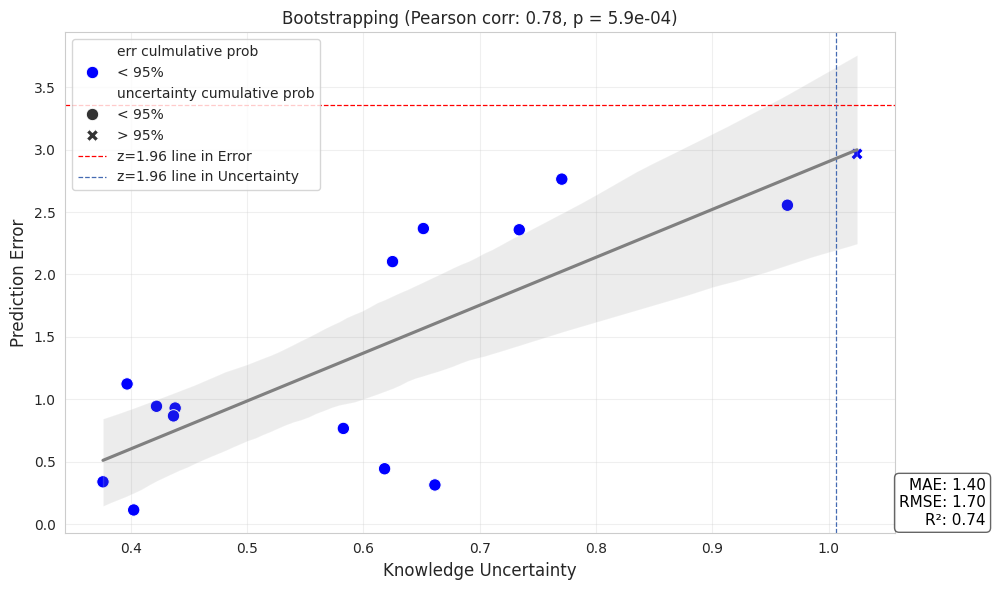

In [ ]:
plot_uncertainty_vs_error(
    data=bootstrap_results,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    mae=mae,
    rmse=rmse,
    r2=r2,
    title="Bootstrapping",
)

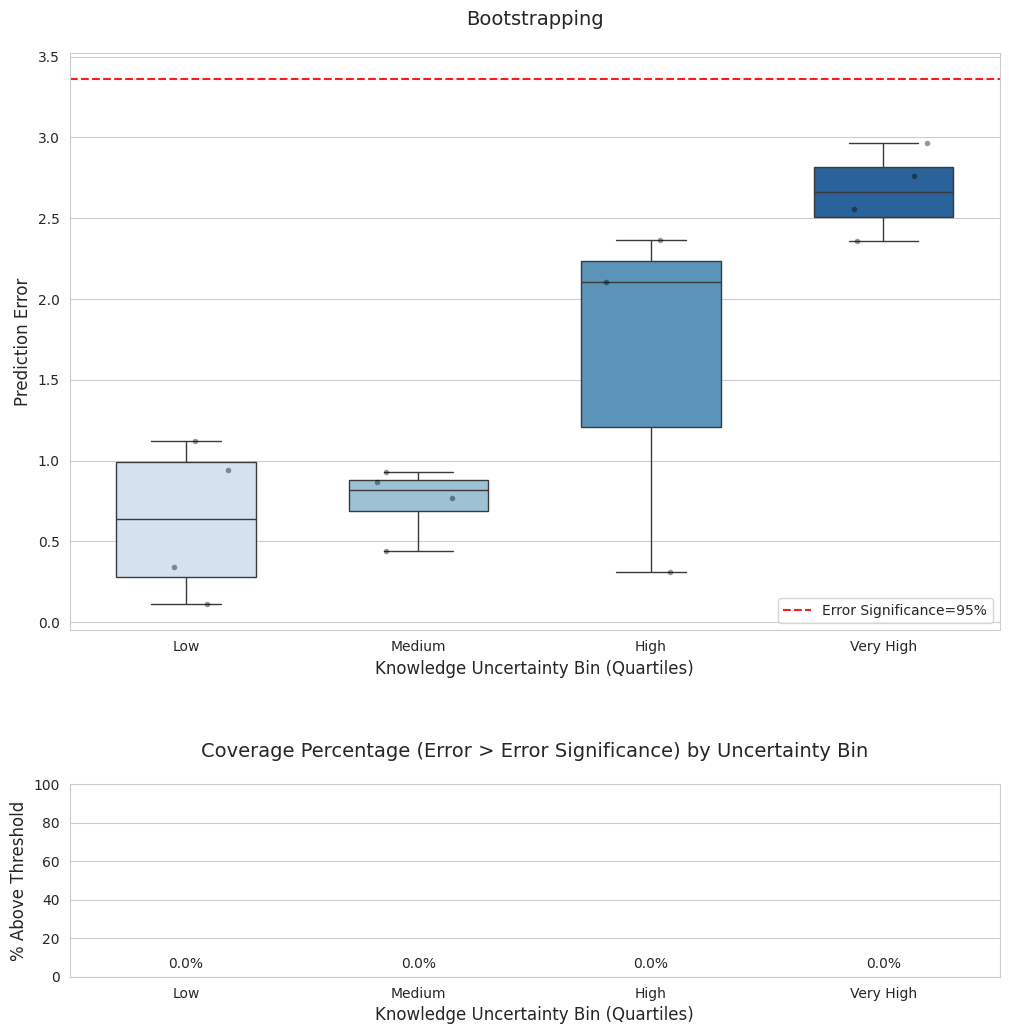

In [ ]:
plot_boxplot_and_coverage(
    data=bootstrap_results,
    knowledge_uncertainty_col="knowledge_uncertainty",
    prediction_error_col="prediction_error",
    title="Bootstrapping",
)

In [ ]:
methods = {
    "Virtual": df_res_rmse[["prediction_error", "knowledge_uncertainty"]],
    "bootstrapping": bootstrap_results[["prediction_error", "knowledge_uncertainty"]],  # , "data_uncertainty"]],
    "RMSEWUncertainty": df_res[["prediction_error", "knowledge_uncertainty"]],  # , "data_uncertainty"]],
    "Guassian": df_res_gauss[["prediction_error", "knowledge_uncertainty"]],
    "Quantile": df_res_quant[
        ["prediction_error", "knowledge_uncertainty"]
    ],  # "data_uncertainty"]], "prediction_error",
}

combined_data = pd.concat([method_df.assign(Method=method) for method, method_df in methods.items()]).reset_index(
    drop=True
)

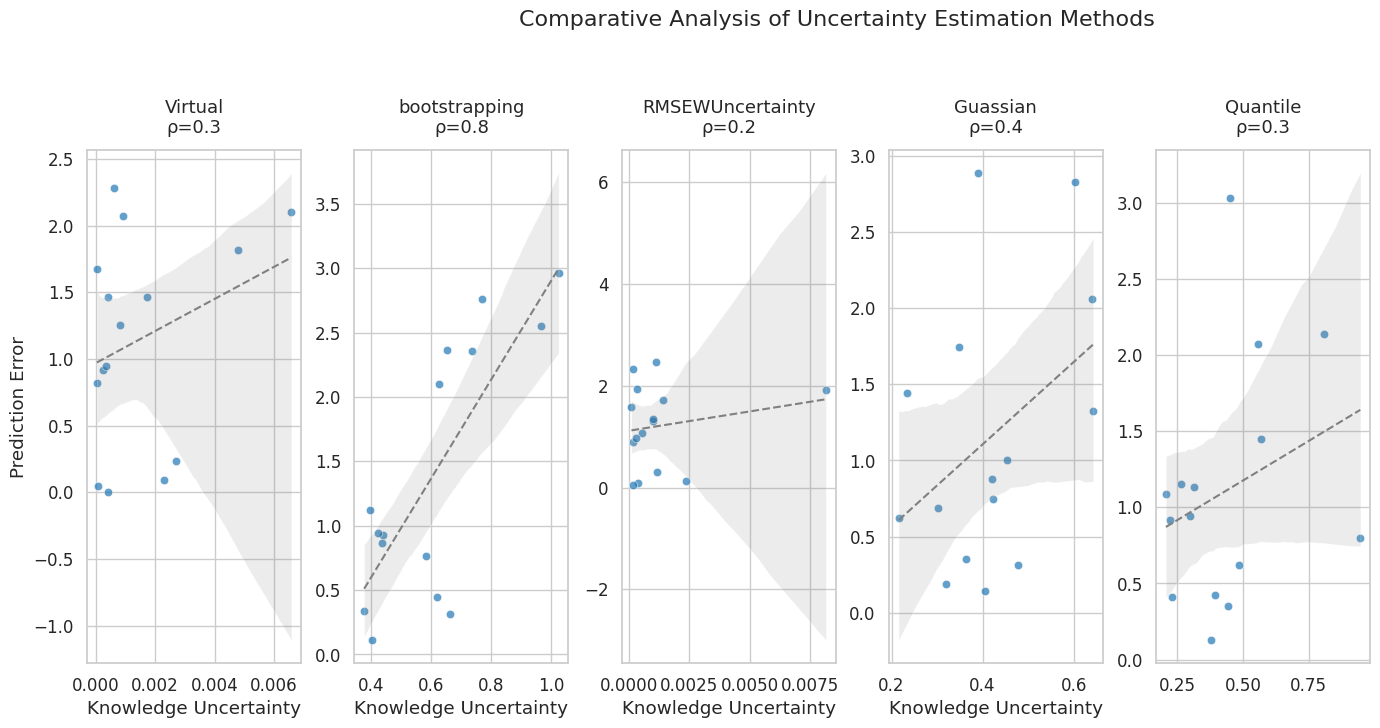

In [ ]:
import matplotlib.gridspec as gridspec

plt.figure(figsize=(20, 14))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create grid layout - 4 columns for 4 methods
gs = gridspec.GridSpec(2, 6, height_ratios=[2, 1.5], hspace=0.4, wspace=0.25)

# Top Row: Method Comparison (4 columns)
for idx, method in enumerate(methods.keys()):
    ax = plt.subplot(gs[0, idx])  # Now 0-3 columns available
    method_data = combined_data[combined_data["Method"] == method]

    sns.scatterplot(
        x="knowledge_uncertainty",
        y="prediction_error",
        data=method_data,
        palette="blue",
        alpha=0.7,
        ax=ax,
    )

    sns.regplot(
        x="knowledge_uncertainty",
        y="prediction_error",
        data=method_data,
        scatter=False,
        color="grey",
        line_kws={"linestyle": "--", "lw": 1.5},
        ax=ax,
    )

    ax.set_title(
        f"{method}\nρ={method_data[['knowledge_uncertainty', 'prediction_error']].corr().iloc[0, 1]:.1f}",
        fontsize=13,
        pad=12,
    )
    ax.set_xlabel("Knowledge Uncertainty" if idx in [0, 1, 2, 3] else "")
    ax.set_ylabel("Prediction Error" if idx == 0 else "")

# make the suptitle in the middle of the figure
# plt.suptitle("Comparative Analysis of Uncertainty Estimation Methods", fontsize=16, y=1.05)
plt.suptitle("Comparative Analysis of Uncertainty Estimation Methods", fontsize=16)
plt.tight_layout()
plt.show()

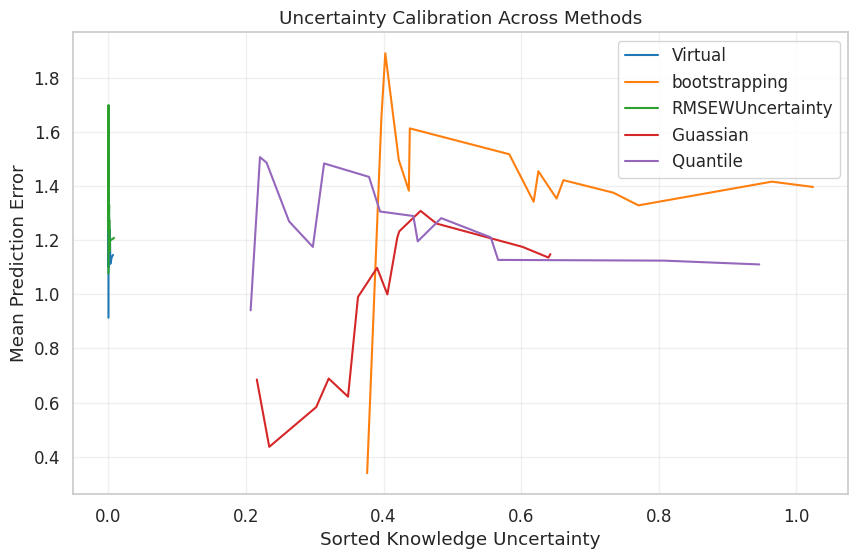

In [ ]:
# Calibration plot
plt.figure(figsize=(10, 6))
for method in methods:
    method_data = combined_data[combined_data["Method"] == method]
    sorted_unc = method_data["knowledge_uncertainty"].sort_values().values
    calib_curve = np.array([method_data["prediction_error"].iloc[:i].mean() for i in range(1, len(sorted_unc) + 1)])

    plt.plot(sorted_unc, calib_curve, label=method)

plt.xlabel("Sorted Knowledge Uncertainty")
plt.ylabel("Mean Prediction Error")
plt.title("Uncertainty Calibration Across Methods")
plt.legend()
plt.grid(alpha=0.3)
plt.show()